## 1.BÖLÜM: Kütüphanelerin Yüklenmesi ve Veri Setinin Hazırlanması

In [8]:
!pip install tensorflow matplotlib numpy

Defaulting to user installation because normal site-packages is not writeable


In [9]:
import tensorflow as tf # Derin öğrenme modelleri oluşturmak için ana kütüphane
from tensorflow.keras import layers, models # Model katmanları ve yapılandırma araçları
import matplotlib.pyplot as plt # Sonuçları görselleştirmek ve grafik çizmek için
import numpy as np # Diziler ve matematiksel işlemler için

# MNIST el yazısı rakamları veri kümesini (Train/Test) olarak internetten çekiyoruz
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Veri boyutlarını kontrol etmek için ekrana yazdırıyoruz
print(f"Eğitim verisi: {x_train.shape}") # 60.000 tane 28x28 boyutunda resim

Eğitim verisi: (60000, 28, 28)


## 2.BÖLÜM: Veri Ön İşleme

In [10]:
# Piksel değerlerini 0-255 arasından 0-1 arasına çekiyoruz (Normalizasyon)
x_train = x_train.astype("float32") / 255.0 # Her pikseli 255'e bölerek float tipine çeviriyoruz
x_test = x_test.astype("float32") / 255.0 # Test verisi için de aynı işlemi yapıyoruz

# CNN katmanları (Batch, Height, Width, Channel) formatında veri beklediği iç
x_train = np.expand_dims(x_train, -1) # 28x28 olan boyutu 28x28x1 (Siyah-Beyaz kanal) yapıyoruz
x_test = np.expand_dims(x_test, -1) # Aynı işlemi test verisi için yapıyoruz
# Etiketleri (0,1,2...9) One-Hot Encoding formatına çeviriyoruz
y_train = tf.keras.utils.to_categorical(y_train, 10) # Sayısal etiketi 10'luk diziye çevirir
y_test = tf.keras.utils.to_categorical(y_test, 10) # Örn: 3 sayısı [0,0,0,1,0,0,0,0,0,0] olur

## 3.BÖLÜM: Model Kurulum Fonksiyonu

In [11]:
def model_olustur(k_boyutu):
    model = models.Sequential([ # Katmanların sırayla birbirini takip ettiği model yapısı
        # İlk Evrişim Katmanı: Filtre sayısı 32, seçilen Kernel boyutu uygulanır
        layers.Conv2D(32,
                      kernel_size=k_boyutu, activation='relu',
                      input_shape=(28, 28, 1)),
        layers.MaxPooling2D(pool_size=(2, 2)), # Boyutu yarıya indirerek önemli özellikleri seçer
        # İkinci Evrişim Katmanı: Filtre sayısı 64
        layers.Conv2D(64, kernel_size=k_boyutu, activation='relu'),
        layers.MaxPooling2D(pool_size=(2, 2)), # Yine boyutu küçülterek hesaplama yükünü azaltır

        layers.Flatten(), # 2 boyutlu haritaları tek boyutlu düz bir vektöre dönüştürür
        layers.Dense(64, activation='relu'), # 64 nöronlu tam bağlantılı gizli katman
        layers.Dense(10, activation='softmax') # 10 sınıf için olasılık üreten çıkış katmanı
    ])

    # Modeli derliyoruz
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model # Hazırlanan modeli geri döndürür

# Üç farklı kernel boyutu için modellerimizi tanımlıyoruz
model_3 = model_olustur((3, 3)) # 3x3 küçük çekirdekler
model_5 = model_olustur((5, 5)) # 5x5 orta çekirdekler
model_7 = model_olustur((7, 7)) # 7x7 büyük çekirdekler

print("Modeller başarıyla oluşturuldu!")
        

Modeller başarıyla oluşturuldu!


## 4.BÖLÜM: Eğitim 

In [12]:
# Her model için 3'er tur (epoch) eğitim yapıyoruz
# verbose=1 ile eğitim sırasındaki ilerleme çubuğunu görüyoruz

print("3x3 Modeli Eğitiliyor...")
h3 = model_3.fit(x_train, y_train, epochs=3, validation_data=(x_test, y_test), verbose=1)

print("\n5x5 Modeli Eğitiliyor...")
h5 = model_5.fit(x_train, y_train, epochs=3, validation_data=(x_test, y_test), verbose=1)

print("\n7x7 Modeli Eğitiliyor...")
h7 = model_7.fit(x_train, y_train, epochs=3, validation_data=(x_test, y_test), verbose=1)

3x3 Modeli Eğitiliyor...
Epoch 1/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9576 - loss: 0.1390 - val_accuracy: 0.9867 - val_loss: 0.0440
Epoch 2/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9853 - loss: 0.0466 - val_accuracy: 0.9883 - val_loss: 0.0344
Epoch 3/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9898 - loss: 0.0323 - val_accuracy: 0.9892 - val_loss: 0.0321

5x5 Modeli Eğitiliyor...
Epoch 1/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9622 - loss: 0.1248 - val_accuracy: 0.9841 - val_loss: 0.0473
Epoch 2/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9874 - loss: 0.0402 - val_accuracy: 0.9901 - val_loss: 0.0304
Epoch 3/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9912 - loss: 0.0285 - val_accuracy: 0.9908 - val_loss: 0.0271

7x7 Modeli Eğitiliyor...
Epoch 1/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9546 - loss: 0.1450 - val_accuracy: 0.9842 - val_loss: 0.0523
Epoch 2/3
1875/18

## 5.BÖLÜM: Görselleştirme ve Sonuç Karşılaştırma

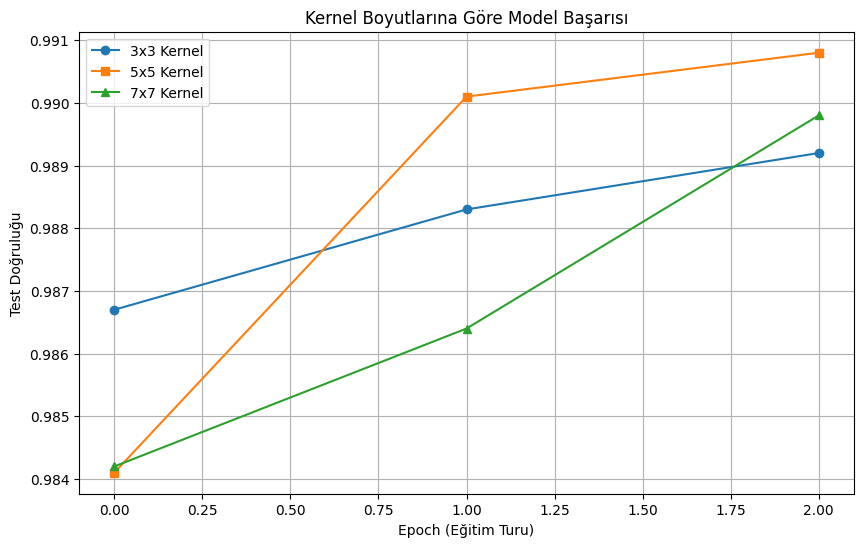

3x3 Toplam Parametre: 121930
5x5 Toplam Parametre: 121930
7x7 Toplam Parametre: 121930


In [13]:
# Grafik için bir alan oluşturuyoruz
plt.figure(figsize=(10, 6))

# Her modelin doğrulama başarısını grafiğe ekliyoruz
plt.plot(h3.history['val_accuracy'], label='3x3 Kernel', marker='o') # 3x3 sonuçları
plt.plot(h5.history['val_accuracy'], label='5x5 Kernel', marker='s') # 5x5 sonuçları
plt.plot(h7.history['val_accuracy'], label='7x7 Kernel', marker='^') # 7x7 sonuçları

plt.title('Kernel Boyutlarına Göre Model Başarısı') # Grafiğin başlığı
plt.xlabel('Epoch (Eğitim Turu)') # X ekseni açıklaması
plt.ylabel('Test Doğruluğu') # Y ekseni açıklaması
plt.legend() # Hangi çizginin hangi modele ait olduğunu gösteren kutu
plt.grid(True) # Izgara çizgilerini açıyoruz
plt.show() # Grafiği ekranda gösterir

# Modellerin karmaşıklığını karşılaştıralım
print(f"3x3 Toplam Parametre: {model_3.count_params()}") # Daha az paraöetre, hızlı
print(f"5x5 Toplam Parametre: {model_3.count_params()}") # Orta seviye parametre
print(f"7x7 Toplam Parametre: {model_3.count_params()}") # Daha çok parametre, yavaş